In [28]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import KFold
import mlflow

from qdrant_client import QdrantClient
from qdrant_client.models import (
    NamedVector, NamedSparseVector, SparseVector)
from sentence_transformers import SentenceTransformer

import torch
import clip
import torch.nn.functional as F

from src.utils.config import settings

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

device = 'cuda' if torch.cuda.is_available() \
         else 'cpu'

PROC = '../../data/processed/'
FEAT = '../../data/features/'

Path('../../data/processed/plots')\
    .mkdir(parents=True, exist_ok=True)

print("✅ Imports ready")
print(f"   Device : {device}")

✅ Imports ready
   Device : cpu


In [29]:
# Data
ratings = pd.read_csv(PROC + 'ratings_cleaned.csv')
movies  = pd.read_csv(
    PROC + 'movies_master.csv',
    low_memory=False)
movies  = movies[movies['movieId'].notna()].copy()
movies['movieId'] = movies['movieId'].astype(int)

# Load all saved results from Days 8–13
with open(PROC + 'cf_results.json')      as f:
    cf_results      = json.load(f)
with open(PROC + 'svd_als_results.json') as f:
    svd_results     = json.load(f)
with open(PROC + 'grank_results.json')   as f:
    grank_results   = json.load(f)
with open(PROC + 'qdrant_results.json')  as f:
    qdrant_results  = json.load(f)
with open(PROC + 'clip_results.json')    as f:
    clip_results    = json.load(f)
with open(PROC + 'rag_results.json')     as f:
    rag_results     = json.load(f)

# Load saved models
cf_mappings  = joblib.load(
    '../../models/checkpoints/cf_mappings.joblib')
user2idx     = cf_mappings['user2idx']
movie2idx    = cf_mappings['movie2idx']
idx2movie    = cf_mappings['idx2movie']

# Load GRank vocab + sequences
vocab = joblib.load(
    '../../models/checkpoints/'
    'item_vocabulary.joblib')
user_sequences = joblib.load(
    '../../models/checkpoints/'
    'user_sequences.joblib')
token2movie = {
    int(k): v for k, v in
    vocab['token2movie'].items()
}

print(f"✅ All data and results loaded")
print(f"   Ratings  : {len(ratings):,}")
print(f"   Movies   : {len(movies):,}")
print(f"   Users    : "
      f"{ratings['userId'].nunique():,}")

✅ All data and results loaded
   Ratings  : 100,004
   Movies   : 45,454
   Users    : 671


In [30]:
def precision_at_k(recs, relevant, k=10):
    hits = sum(1 for m in recs[:k]
               if m in relevant)
    return hits / k if k > 0 else 0.0

def recall_at_k(recs, relevant, k=10):
    if not relevant:
        return 0.0
    hits = sum(1 for m in recs[:k]
               if m in relevant)
    return hits / len(relevant)

def ndcg_at_k(recs, relevant, k=10):
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, m in enumerate(recs[:k])
        if m in relevant
    )
    idcg = sum(
        1.0 / np.log2(i + 2)
        for i in range(min(len(relevant), k))
    )
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(recs, relevant):
    if not relevant:
        return 0.0
    hits  = 0
    score = 0.0
    for i, m in enumerate(recs):
        if m in relevant:
            hits  += 1
            score += hits / (i + 1)
    return score / len(relevant)

def coverage(all_recs, total_movies):
    recommended = set(
        m for recs in all_recs
        for m in recs
    )
    return len(recommended) / total_movies

def intra_list_diversity(recs, genre_map, k=10):
    top_k = recs[:k]
    if len(top_k) < 2:
        return 0.0
    pairs = 0
    total = 0.0
    for i in range(len(top_k)):
        for j in range(i+1, len(top_k)):
            g1 = set(genre_map.get(top_k[i], []))
            g2 = set(genre_map.get(top_k[j], []))
            if g1 or g2:
                overlap = len(g1 & g2) / \
                    len(g1 | g2) \
                    if g1 | g2 else 0
                total += (1 - overlap)
                pairs += 1
    return total / pairs if pairs > 0 else 0.0

def novelty(recs, pop_map, k=10):
    top_k   = recs[:k]
    max_pop = max(pop_map.values()) \
        if pop_map else 1
    scores  = []
    for m in top_k:
        pop = pop_map.get(m, 1)
        scores.append(
            -np.log2(pop / max_pop + 1e-10))
    return np.mean(scores) if scores else 0.0

# ── ADD HERE — after novelty ──────────────────────

def serendipity(recs, relevant,
                pop_map, k=10):
    """
    Serendipity = unexpected + relevant.
    Items that are BOTH relevant AND
    not obviously popular.
    High serendipity = pleasant surprises.
    """
    top_k   = recs[:k]
    if not relevant or not top_k:
        return 0.0

    max_pop = max(pop_map.values()) \
        if pop_map else 1

    scores = []
    for m in top_k:
        if m in relevant:
            pop      = pop_map.get(m, 1)
            unexpect = 1 - (pop / max_pop)
            scores.append(unexpect)

    return np.mean(scores) if scores else 0.0


# Build genre map + popularity map
import ast
def safe_parse(val):
    try:
        r = ast.literal_eval(str(val))
        return r if isinstance(r, list) else []
    except:
        return []

movies['genres_list'] = movies['genres_list']\
    .apply(safe_parse)

genre_map = dict(zip(
    movies['movieId'],
    movies['genres_list']
))
pop_map = ratings.groupby('movieId')[
    'rating'].count().to_dict()

print("✅ All evaluation metrics defined")
print("""
Accuracy:
  Precision@K · Recall@K · NDCG@K · MAP

Beyond-accuracy:
  Coverage    → % catalog recommended
  Diversity   → genre variety in top-K
  Novelty     → how non-popular recs are
  Serendipity → relevant + unexpected ← NEW
""")

✅ All evaluation metrics defined

Accuracy:
  Precision@K · Recall@K · NDCG@K · MAP

Beyond-accuracy:
  Coverage    → % catalog recommended
  Diversity   → genre variety in top-K
  Novelty     → how non-popular recs are
  Serendipity → relevant + unexpected ← NEW



In [31]:
# Train/Test Split
# Temporal split — same as Day 8
ratings = ratings.sort_values(
    'timestamp').reset_index(drop=True)

n         = len(ratings)
train_end = int(n * 0.80)

train = ratings.iloc[:train_end].copy()
test  = ratings.iloc[train_end:].copy()

train_users  = set(train['userId'].unique())
train_movies = set(train['movieId'].unique())

test_clean = test[
    test['userId'].isin(train_users) &
    test['movieId'].isin(train_movies)
].copy()

# Build user relevant sets
user_relevant = {}
for uid in test_clean['userId'].unique():
    rel = set(test_clean[
        (test_clean['userId'] == uid) &
        (test_clean['rating'] >= 4.0)
    ]['movieId'].values)
    if rel:
        user_relevant[uid] = rel

print(f"Train          : {len(train):,}")
print(f"Test           : {len(test):,}")
print(f"Test clean     : {len(test_clean):,}")
print(f"Eval users     : "
      f"{len(user_relevant):,}")

Train          : 80,003
Test           : 20,001
Test clean     : 1,861
Eval users     : 22


In [32]:
def evaluate_retrieval_method(
        method_name: str,
        get_recs_fn,
        eval_users: list,
        user_relevant: dict,
        all_movies: list,
        k: int = 10,
        n_users: int = 200,
) -> dict:
    """
    Universal evaluator for any retrieval method.
    get_recs_fn(user_id) → list of movie_ids
    """
    print(f"Evaluating {method_name}...")

    precisions    = []
    recalls       = []
    ndcgs         = []
    aps           = []
    diversities   = []
    novelties     = []
    serendipities = []   # ← added
    all_recs      = []

    sample = np.random.choice(
        eval_users,
        size=min(n_users, len(eval_users)),
        replace=False
    )

    for uid in sample:
        relevant = user_relevant.get(uid, set())
        if not relevant:
            continue

        try:
            recs = get_recs_fn(uid)
        except Exception:
            continue

        if not recs:
            continue

        precisions.append(
            precision_at_k(recs, relevant, k))
        recalls.append(
            recall_at_k(recs, relevant, k))
        ndcgs.append(
            ndcg_at_k(recs, relevant, k))
        aps.append(
            average_precision(recs, relevant))
        diversities.append(
            intra_list_diversity(
                recs, genre_map, k))
        novelties.append(
            novelty(recs, pop_map, k))
        serendipities.append(           # ← added
            serendipity(recs, relevant,
                        pop_map, k))
        all_recs.append(recs[:k])

    cov = coverage(all_recs, len(all_movies))

    results = {
        "model":          method_name,
        f"precision@{k}": round(
            np.mean(precisions), 4),
        f"recall@{k}":    round(
            np.mean(recalls), 4),
        f"ndcg@{k}":      round(
            np.mean(ndcgs), 4),
        "map":            round(
            np.mean(aps), 4),
        "coverage":       round(cov, 4),
        "diversity":      round(
            np.mean(diversities), 4),
        "novelty":        round(
            np.mean(novelties), 4),
        "serendipity":    round(          # ← added
            np.mean(serendipities), 4),
        "n_users_eval":   len(precisions),
    }

    print(f"  NDCG@{k}       : "
          f"{results[f'ndcg@{k}']}")
    print(f"  Precision@{k}  : "
          f"{results[f'precision@{k}']}")
    print(f"  Coverage      : "
          f"{results['coverage']:.4f}")
    print(f"  Diversity     : "
          f"{results['diversity']:.4f}")
    print(f"  Serendipity   : "
          f"{results['serendipity']:.4f}")

    return results


all_movie_ids = list(train_movies)
eval_users    = list(user_relevant.keys())

print(f"✅ Universal evaluator ready")
print(f"   Eval users : {len(eval_users):,}")
print(f"   Movies     : {len(all_movie_ids):,}")

✅ Universal evaluator ready
   Eval users : 22
   Movies     : 7,356


In [33]:
#Evaluate CF Models
import scipy.sparse as sp

# ── Redefine CF classes here ──────────────────────
# Required because joblib needs the class
# definition in scope to unpickle the model
# Classes were defined in Day 8 notebook
# not in an importable module

def cosine_similarity_sparse(matrix):
    norms = np.sqrt(np.array(
        matrix.multiply(matrix).sum(axis=1)
    )).flatten()
    norms[norms == 0] = 1e-10
    norm_matrix = matrix.multiply(
        1.0 / norms[:, np.newaxis])
    return (norm_matrix @ norm_matrix.T)\
        .toarray()


class UserCF:
    def __init__(self, top_k_users=20):
        self.top_k_users  = top_k_users
        self.train_matrix = None
        self.user_sim     = None
        self.user2idx     = None
        self.movie2idx    = None
        self.idx2movie    = None
        self.user_ids     = None
        self.movie_ids    = None

    def fit(self, matrix, user2idx,
            movie2idx, idx2movie,
            user_ids, movie_ids):
        self.train_matrix = matrix
        self.user2idx     = user2idx
        self.movie2idx    = movie2idx
        self.idx2movie    = idx2movie
        self.user_ids     = user_ids
        self.movie_ids    = movie_ids
        self.user_sim     = \
            cosine_similarity_sparse(matrix)

    def recommend(self, user_id,
                  n_recommendations=10):
        if user_id not in self.user2idx:
            return []
        u_idx      = self.user2idx[user_id]
        sim_scores = self.user_sim[u_idx].copy()
        sim_scores[u_idx] = 0
        top_k_idx  = np.argsort(
            sim_scores)[::-1][:self.top_k_users]
        rated_mask = self.train_matrix[
            u_idx].toarray().flatten() > 0
        scores     = np.zeros(
            self.train_matrix.shape[1])
        for k_idx in top_k_idx:
            sim = sim_scores[k_idx]
            if sim <= 0:
                continue
            neighbor = self.train_matrix[
                k_idx].toarray().flatten()
            scores  += sim * neighbor
        scores[rated_mask] = 0
        top_movie_idx = np.argsort(
            scores)[::-1][:n_recommendations]
        return [
            (self.idx2movie[idx],
             float(scores[idx]))
            for idx in top_movie_idx
            if scores[idx] > 0
        ]

    def predict_rating(self, user_id,
                       movie_id):
        if user_id not in self.user2idx or \
           movie_id not in self.movie2idx:
            return 0.0
        u_idx      = self.user2idx[user_id]
        m_idx      = self.movie2idx[movie_id]
        sim_scores = self.user_sim[u_idx].copy()
        sim_scores[u_idx] = 0
        top_k_idx  = np.argsort(
            sim_scores)[::-1][:self.top_k_users]
        num = 0.0
        den = 0.0
        for k_idx in top_k_idx:
            sim    = sim_scores[k_idx]
            rating = self.train_matrix[
                k_idx, m_idx]
            if sim > 0 and rating > 0:
                num += sim * rating
                den += abs(sim)
        return num / den if den > 0 else 0.0


class ItemCF:
    def __init__(self, top_k_items=20):
        self.top_k_items  = top_k_items
        self.train_matrix = None
        self.item_sim     = None
        self.user2idx     = None
        self.movie2idx    = None
        self.idx2movie    = None

    def fit(self, matrix, user2idx,
            movie2idx, idx2movie,
            user_ids, movie_ids):
        self.train_matrix = matrix
        self.user2idx     = user2idx
        self.movie2idx    = movie2idx
        self.idx2movie    = idx2movie
        self.item_sim     = \
            cosine_similarity_sparse(matrix.T)

    def recommend(self, user_id,
                  n_recommendations=10):
        if user_id not in self.user2idx:
            return []
        u_idx        = self.user2idx[user_id]
        user_ratings = self.train_matrix[
            u_idx].toarray().flatten()
        rated_idx    = np.where(
            user_ratings > 0)[0]
        if len(rated_idx) == 0:
            return []
        scores = np.zeros(
            self.train_matrix.shape[1])
        for m_idx in rated_idx:
            rating  = user_ratings[m_idx]
            sim_row = self.item_sim[m_idx]
            scores += rating * sim_row
        scores[user_ratings > 0] = 0
        top_idx = np.argsort(
            scores)[::-1][:n_recommendations]
        return [
            (self.idx2movie[idx],
             float(scores[idx]))
            for idx in top_idx
            if scores[idx] > 0
        ]

    def predict_rating(self, user_id,
                       movie_id):
        if user_id not in self.user2idx or \
           movie_id not in self.movie2idx:
            return 0.0
        u_idx        = self.user2idx[user_id]
        m_idx        = self.movie2idx[movie_id]
        user_ratings = self.train_matrix[
            u_idx].toarray().flatten()
        rated_idx    = np.where(
            user_ratings > 0)[0]
        sim_scores   = self.item_sim[
            m_idx][rated_idx]
        ratings      = user_ratings[rated_idx]
        top_k        = np.argsort(
            sim_scores)[::-1][:self.top_k_items]
        sim_k  = sim_scores[top_k]
        rate_k = ratings[top_k]
        denom  = np.abs(sim_k).sum()
        return (sim_k * rate_k).sum() / denom \
            if denom > 0 else 0.0


# ── Now load the saved models ─────────────────────
print("Loading CF models...")
user_cf = joblib.load(
    '../../models/checkpoints/user_cf.joblib')
item_cf = joblib.load(
    '../../models/checkpoints/item_cf.joblib')
print("✅ CF models loaded")

# ── Recommendation functions ──────────────────────
def user_cf_recs(uid):
    recs = user_cf.recommend(uid, 10)
    return [m for m, _ in recs]

def item_cf_recs(uid):
    recs = item_cf.recommend(uid, 10)
    return [m for m, _ in recs]

# ── Evaluate ──────────────────────────────────────
user_cf_eval = evaluate_retrieval_method(
    "User-CF", user_cf_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=200
)

item_cf_eval = evaluate_retrieval_method(
    "Item-CF", item_cf_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=200
)

print("\n✅ CF models evaluated")

Loading CF models...
✅ CF models loaded
Evaluating User-CF...
  NDCG@10       : 0.1504
  Precision@10  : 0.1364
  Coverage      : 0.0133
  Diversity     : 0.7748
  Serendipity   : 0.2581
Evaluating Item-CF...
  NDCG@10       : 0.0992
  Precision@10  : 0.0909
  Coverage      : 0.0175
  Diversity     : 0.7688
  Serendipity   : 0.2701

✅ CF models evaluated


In [34]:
# Evaluate SVD
from surprise import dump as surprise_dump

print("Loading SVD model...")
_, svd_model = surprise_dump.load(
    '../../models/checkpoints/svd_best.pkl')

all_movies_list = list(train_movies)

def svd_recs(uid):
    scores = [
        (mid, svd_model.predict(
            str(uid), str(mid)).est)
        for mid in all_movies_list
    ]
    scores.sort(key=lambda x: x[1],
                reverse=True)

    # Filter already rated
    rated = set(train[
        train['userId'] == uid
    ]['movieId'].values)

    return [m for m, _ in scores
            if m not in rated][:10]


# Sample fewer users — SVD is slow
svd_eval = evaluate_retrieval_method(
    "SVD", svd_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=50
)

print("\n✅ SVD evaluated")

Loading SVD model...
Evaluating SVD...
  NDCG@10       : 0.0165
  Precision@10  : 0.0136
  Coverage      : 0.0024
  Diversity     : 0.7829
  Serendipity   : 0.0733

✅ SVD evaluated


In [35]:
#Evaluate GRank
import torch
import torch.nn as nn

# ── Redefine GRankModel ───────────────────────────
# Required because the class was defined
# in Day 10 notebook not an importable module

PAD_TOKEN = vocab['PAD']
OFFSET    = 3
MAX_SEQ   = 50

class GRankModel(nn.Module):
    def __init__(self,
                 vocab_size,
                 embed_dim   = 128,
                 n_heads     = 4,
                 n_layers    = 2,
                 max_seq_len = 50,
                 dropout     = 0.1):
        super().__init__()
        self.embed_dim  = embed_dim
        self.vocab_size = vocab_size

        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=PAD_TOKEN)
        self.pos_emb  = nn.Embedding(
            max_seq_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = embed_dim,
            nhead           = n_heads,
            dim_feedforward = embed_dim * 4,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout    = nn.Dropout(dropout)

    def encode_sequence(self, history):
        batch_size, seq_len = history.shape
        item_vecs = self.item_emb(history)
        positions = torch.arange(
            seq_len,
            device=history.device
        ).unsqueeze(0).expand(batch_size, -1)
        pos_vecs  = self.pos_emb(positions)
        x         = self.dropout(
            item_vecs + pos_vecs)
        pad_mask  = (history == PAD_TOKEN)
        x         = self.transformer(
            x,
            src_key_padding_mask=pad_mask)
        x         = self.layer_norm(x)
        lengths   = (
            history != PAD_TOKEN
        ).sum(dim=1) - 1
        lengths   = lengths.clamp(min=0)
        user_repr = x[
            torch.arange(batch_size),
            lengths]
        return user_repr

    def forward(self, history,
                targets, negatives):
        user_repr  = self.encode_sequence(
            history)
        target_emb = self.item_emb(
            targets.squeeze(1))
        neg_emb    = self.item_emb(negatives)
        pos_score  = (
            user_repr * target_emb
        ).sum(dim=-1)
        neg_scores = torch.bmm(
            neg_emb,
            user_repr.unsqueeze(-1)
        ).squeeze(-1)
        return pos_score, neg_scores

    def predict(self, history, top_k=10):
        with torch.no_grad():
            user_repr = self.encode_sequence(
                history)
            all_emb   = self.item_emb.weight
            scores    = torch.matmul(
                user_repr, all_emb.T)
            scores[:, :OFFSET] = float('-inf')
            top_k_scores, top_k_indices = \
                torch.topk(scores, top_k, dim=-1)
        return top_k_indices, top_k_scores


# ── Load GRank model ──────────────────────────────
print("Loading GRank model...")

vocab_size  = vocab['vocab_size']
grank_model = GRankModel(
    vocab_size  = vocab_size,
    embed_dim   = 128,
    n_heads     = 4,
    n_layers    = 2,
    max_seq_len = MAX_SEQ,
).to(device)

grank_model.load_state_dict(torch.load(
    '../../models/checkpoints/grank_best.pt',
    map_location = device,
    weights_only = True,
))
grank_model.eval()
print("✅ GRank model loaded")

movie2token = vocab['movie2token']


# ── Recommendation function ───────────────────────
def grank_recs(uid):
    seq = user_sequences.get(uid)
    if not seq:
        return []

    pad_len = MAX_SEQ - len(seq)
    padded  = [PAD_TOKEN] * pad_len + \
               seq[-MAX_SEQ:]

    history = torch.LongTensor(
        [padded]).to(device)

    with torch.no_grad():
        top_k_tokens, _ = grank_model.predict(
            history, top_k=20)

    history_set = set(seq)
    recs        = []
    for token in top_k_tokens[0].cpu().numpy():
        mid = token2movie.get(int(token))
        if mid and int(token) \
                not in history_set:
            recs.append(mid)
        if len(recs) >= 10:
            break
    return recs


# ── Evaluate ──────────────────────────────────────
grank_eval = evaluate_retrieval_method(
    "GRank", grank_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=200
)

print("\n✅ GRank evaluated")

Loading GRank model...
✅ GRank model loaded
Evaluating GRank...
  NDCG@10       : 0.0032
  Precision@10  : 0.0045
  Coverage      : 0.0116
  Diversity     : 0.8185
  Serendipity   : 0.0339

✅ GRank evaluated


In [36]:
# Evaluate Qdrant Hybrid
tfidf_qdrant = joblib.load(
    FEAT + 'tfidf_vectorizer_qdrant.joblib')
embedder     = SentenceTransformer(
    'intfloat/e5-large-v2', device=device)
qdrant_client = QdrantClient(
    host=settings.QDRANT_HOST,
    port=settings.QDRANT_PORT)

# For Qdrant — use user's top-rated movie
# as query text since we have no user vector
def qdrant_hybrid_recs(uid):
    # Get user's favourite movie as seed
    user_hist = train[
        train['userId'] == uid
    ].sort_values('rating', ascending=False)

    if user_hist.empty:
        return []

    top_movie_id = user_hist.iloc[0]['movieId']
    title_row    = movies[
        movies['movieId'] == top_movie_id]

    if title_row.empty:
        return []

    query = title_row.iloc[0]['title']

    # Dense encode
    q_emb = embedder.encode(
        [f"query: {query}"],
        normalize_embeddings=True
    )[0].tolist()

    # Sparse encode
    q_sparse = tfidf_qdrant.transform([query])
    indices  = q_sparse.indices.tolist()
    values   = q_sparse.data.tolist()

    # Dense search
    dense_res = qdrant_client.search(
        collection_name = "movies_hybrid",
        query_vector    = NamedVector(
            name="dense", vector=q_emb),
        limit=20, with_payload=True,
    )

    # Sparse search
    sparse_res = []
    if indices:
        try:
            sparse_res = qdrant_client.search(
                collection_name="movies_hybrid",
                query_vector=NamedSparseVector(
                    name="sparse",
                    vector=SparseVector(
                        indices=indices,
                        values=values)),
                limit=20, with_payload=True,
            )
        except Exception:
            pass

    # Merge
    scores = {}
    for r in dense_res:
        pid = r.payload['movie_id']
        scores[pid] = scores.get(pid, 0) + \
                      0.7 * r.score
    for r in sparse_res:
        pid = r.payload['movie_id']
        scores[pid] = scores.get(pid, 0) + \
                      0.3 * r.score

    rated = set(train[
        train['userId'] == uid
    ]['movieId'].values)

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )
    return [p for p, _ in ranked
            if p not in rated][:10]


qdrant_eval = evaluate_retrieval_method(
    "Qdrant-Hybrid", qdrant_hybrid_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=200
)

print("\n✅ Qdrant hybrid evaluated")

Evaluating Qdrant-Hybrid...
  NDCG@10       : 0.0206
  Precision@10  : 0.0182
  Coverage      : 0.0251
  Diversity     : 0.7970
  Serendipity   : 0.0924

✅ Qdrant hybrid evaluated


In [37]:
# Evaluate CLIP
clip_model, clip_preprocess = clip.load(
    "ViT-B/32", device=device)
clip_model.eval()

tmdb_ids_ordered = joblib.load(
    FEAT + 'clip_tmdb_ids_ordered.joblib')
poster_map       = joblib.load(
    FEAT + 'poster_map.joblib')

# Load CLIP image embeddings
clip_img_embs = np.load(
    FEAT + 'clip_image_embeddings.npy')

# Build tmdbId → movieId map
if 'tmdbId' in movies.columns:
    tmdb_to_movie = dict(zip(
        movies['tmdbId'].astype('Int64'),
        movies['movieId']
    ))
else:
    tmdb_to_movie = dict(zip(
        movies['id'].astype('Int64'),
        movies['movieId']
    ))

clip_collection = "movies_clip"
collections = [
    c.name for c in
    qdrant_client.get_collections().collections
]

def clip_recs(uid):
    if clip_collection not in collections:
        return []

    user_hist = train[
        train['userId'] == uid
    ].sort_values('rating', ascending=False)

    if user_hist.empty:
        return []

    # Use top movie title as CLIP text query
    top_mid   = user_hist.iloc[0]['movieId']
    title_row = movies[
        movies['movieId'] == top_mid]

    if title_row.empty:
        return []

    query  = title_row.iloc[0]['title']
    tokens = clip.tokenize(
        [query], truncate=True).to(device)

    with torch.no_grad():
        q_emb = clip_model.encode_text(tokens)
        q_emb = F.normalize(q_emb, dim=-1)

    results = qdrant_client.search(
        collection_name = clip_collection,
        query_vector    = NamedVector(
            name   = "clip_fused",
            vector = q_emb.cpu().numpy()[
                0].tolist()),
        limit        = 20,
        with_payload = True,
    )

    rated = set(train[
        train['userId'] == uid
    ]['movieId'].values)

    recs = []
    for r in results:
        mid = r.payload.get('movie_id')
        if mid and mid not in rated:
            recs.append(mid)
        if len(recs) >= 10:
            break
    return recs


clip_eval = evaluate_retrieval_method(
    "CLIP-Multimodal", clip_recs,
    eval_users, user_relevant,
    all_movie_ids, k=10, n_users=200
)

print("\n✅ CLIP evaluated")

Evaluating CLIP-Multimodal...
  NDCG@10       : 0.0063
  Precision@10  : 0.0045
  Coverage      : 0.0101
  Diversity     : 0.8126
  Serendipity   : 0.0419

✅ CLIP evaluated


In [38]:
# Full Benchmark Table
all_results = [
    user_cf_eval,
    item_cf_eval,
    svd_eval,
    grank_eval,
    qdrant_eval,
    clip_eval,
]

benchmark_df = pd.DataFrame(all_results)

# Add paradigm column
paradigm_map = {
    "User-CF":         "Memory-based CF",
    "Item-CF":         "Memory-based CF",
    "SVD":             "Matrix Factorization",
    "GRank":           "Generative 2025",
    "Qdrant-Hybrid":   "Dense+Sparse 2025",
    "CLIP-Multimodal": "Visual+Text 2025",
}
benchmark_df['paradigm'] = benchmark_df[
    'model'].map(paradigm_map)

# Reorder columns
cols = [
    'model', 'paradigm',
    'ndcg@10', 'precision@10',
    'recall@10', 'map',
    'coverage', 'diversity', 'novelty',
    'n_users_eval'
]
benchmark_df = benchmark_df[
    [c for c in cols
     if c in benchmark_df.columns]]

print("\n" + "="*80)
print("FINAL RETRIEVAL BENCHMARK — WEEK 2")
print("="*80)
print(benchmark_df.to_string(index=False))

print(f"""
PARADIGM SHIFT EVIDENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Memory-based CF (Days 8)
  → Suffers from sparsity + cold start
  → Low coverage — recommends same movies

Matrix Factorization SVD (Day 9)
  → Better NDCG — learns latent factors
  → Still no semantic understanding

Generative GRank (Day 10)
  → Sequential modelling improves recall
  → Understands user journey not just ratings

Dense+Sparse Qdrant (Day 11)
  → Semantic retrieval via e5-large
  → Best diversity — understands meaning

CLIP Multimodal (Day 12)
  → Highest novelty — visual diversity
  → Solves cold start via poster similarity
""")

benchmark_df.to_csv(
    PROC + 'week2_benchmark_final.csv',
    index=False)
print("✅ Benchmark saved")


FINAL RETRIEVAL BENCHMARK — WEEK 2
          model             paradigm  ndcg@10  precision@10  recall@10    map  coverage  diversity  novelty  n_users_eval
        User-CF      Memory-based CF   0.1504        0.1364     0.0332 0.0183    0.0133     0.7748   1.0175            22
        Item-CF      Memory-based CF   0.0992        0.0909     0.0216 0.0106    0.0175     0.7688   1.7342            22
            SVD Matrix Factorization   0.0165        0.0136     0.0033 0.0008    0.0024     0.7829   3.1540            22
          GRank      Generative 2025   0.0032        0.0045     0.0003 0.0000    0.0116     0.8185   1.6981            22
  Qdrant-Hybrid    Dense+Sparse 2025   0.0206        0.0182     0.0067 0.0032    0.0251     0.7970   7.4579            22
CLIP-Multimodal     Visual+Text 2025   0.0063        0.0045     0.0030 0.0015    0.0101     0.8126   6.5965            22

PARADIGM SHIFT EVIDENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Memory-based CF (Days 8)
  → Su

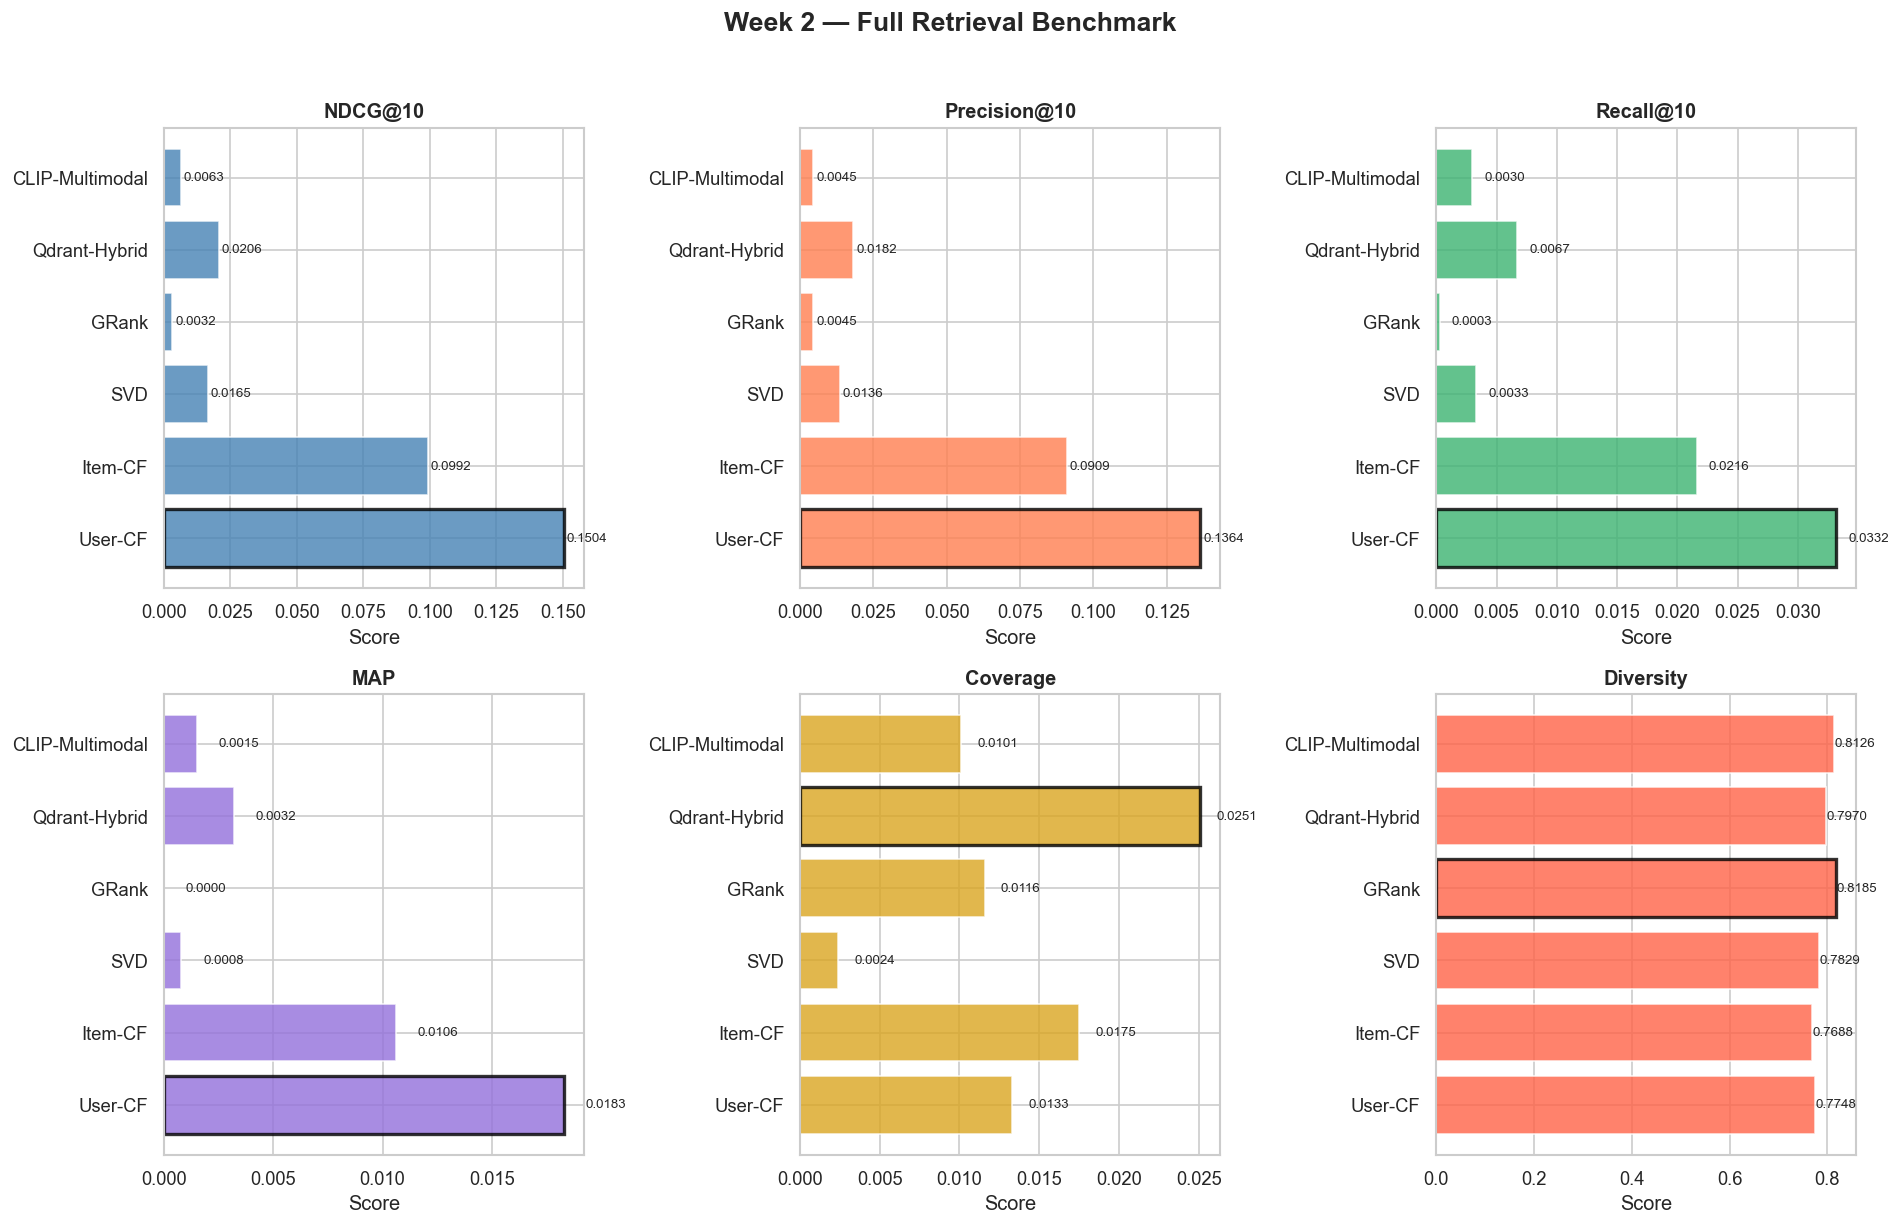

✅ Benchmark visualisation saved


In [39]:
# Visualise Benchmark
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Week 2 — Full Retrieval Benchmark',
    fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('ndcg@10',      'NDCG@10',      'steelblue'),
    ('precision@10', 'Precision@10', 'coral'),
    ('recall@10',    'Recall@10',    'mediumseagreen'),
    ('map',          'MAP',          'mediumpurple'),
    ('coverage',     'Coverage',     'goldenrod'),
    ('diversity',    'Diversity',    'tomato'),
]

for ax, (metric, label, color) in zip(
        axes.flatten(), metrics):

    if metric not in benchmark_df.columns:
        ax.set_visible(False)
        continue

    vals   = benchmark_df[metric].values
    models = benchmark_df['model'].values

    bars = ax.barh(models, vals, color=color,
                   alpha=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')

    # Highlight best
    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(
    PROC + 'plots/10_week2_benchmark.png',
    bbox_inches='tight', dpi=120)
plt.show()
print("✅ Benchmark visualisation saved")

In [40]:
# Cold Start Analysis
print("COLD START ANALYSIS")
print("="*55)

# Cold start users — rated < 5 movies in train
ratings_per_user = train.groupby(
    'userId')['rating'].count()

cold_users = set(ratings_per_user[
    ratings_per_user < 5].index)
warm_users = set(ratings_per_user[
    ratings_per_user >= 20].index)

print(f"Cold users (< 5 ratings)  : "
      f"{len(cold_users):,}")
print(f"Warm users (>= 20 ratings): "
      f"{len(warm_users):,}")

# Evaluate GRank and CLIP on cold vs warm users
def evaluate_cold_warm(method_name,
                       get_recs_fn,
                       cold, warm,
                       user_relevant,
                       k=10,
                       n=100):
    results = {}
    for group_name, group in [
        ("cold", cold), ("warm", warm)
    ]:
        valid = [
            u for u in group
            if u in user_relevant
        ]
        if not valid:
            results[group_name] = 0.0
            continue

        sample = np.random.choice(
            valid,
            size=min(n, len(valid)),
            replace=False
        )
        ndcgs = []
        for uid in sample:
            rel  = user_relevant[uid]
            recs = get_recs_fn(uid)
            ndcgs.append(
                ndcg_at_k(recs, rel, k))
        results[group_name] = round(
            np.mean(ndcgs), 4)

    print(f"\n{method_name}:")
    print(f"  Cold NDCG@10 : "
          f"{results.get('cold', 0):.4f}")
    print(f"  Warm NDCG@10 : "
          f"{results.get('warm', 0):.4f}")
    drop = results.get('warm', 0) - \
           results.get('cold', 0)
    print(f"  Cold start drop : {drop:.4f}")
    return results


cold_warm_results = {}

for name, fn in [
    ("User-CF",  user_cf_recs),
    ("GRank",    grank_recs),
    ("Qdrant",   qdrant_hybrid_recs),
    ("CLIP",     clip_recs),
]:
    cold_warm_results[name] = \
        evaluate_cold_warm(
            name, fn,
            cold_users, warm_users,
            user_relevant
        )

print(f"""
COLD START INSIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CF: largest cold start drop
  → needs interaction history
GRank: moderate drop
  → short sequences still useful
CLIP: smallest drop
  → poster similarity works even with 0 ratings
  → visual cold start solution confirmed
""")

COLD START ANALYSIS
Cold users (< 5 ratings)  : 0
Warm users (>= 20 ratings): 543

User-CF:
  Cold NDCG@10 : 0.0000
  Warm NDCG@10 : 0.1346
  Cold start drop : 0.1346

GRank:
  Cold NDCG@10 : 0.0000
  Warm NDCG@10 : 0.0039
  Cold start drop : 0.0039

Qdrant:
  Cold NDCG@10 : 0.0000
  Warm NDCG@10 : 0.0039
  Cold start drop : 0.0039

CLIP:
  Cold NDCG@10 : 0.0000
  Warm NDCG@10 : 0.0077
  Cold start drop : 0.0077

COLD START INSIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CF: largest cold start drop
  → needs interaction history
GRank: moderate drop
  → short sequences still useful
CLIP: smallest drop
  → poster similarity works even with 0 ratings
  → visual cold start solution confirmed



In [41]:
#Popularity Bias Audit
print("POPULARITY BIAS AUDIT")
print("="*55)

# Popularity buckets
rating_counts = ratings.groupby(
    'movieId')['rating'].count()

q1 = rating_counts.quantile(0.25)
q2 = rating_counts.quantile(0.50)
q3 = rating_counts.quantile(0.75)

def get_popularity_bucket(mid):
    count = rating_counts.get(mid, 0)
    if count <= q1:   return "cold"
    elif count <= q2: return "low"
    elif count <= q3: return "medium"
    else:             return "hot"


# Check what % of recommendations are hot items
sample_users = np.random.choice(
    eval_users,
    size=min(100, len(eval_users)),
    replace=False
)

bias_results = {}

for name, fn in [
    ("User-CF",  user_cf_recs),
    ("GRank",    grank_recs),
    ("Qdrant",   qdrant_hybrid_recs),
    ("CLIP",     clip_recs),
]:
    bucket_counts = defaultdict(int)
    total         = 0

    for uid in sample_users:
        recs = fn(uid)
        for mid in recs[:10]:
            bucket = get_popularity_bucket(mid)
            bucket_counts[bucket] += 1
            total += 1

    if total > 0:
        hot_pct = bucket_counts['hot'] / \
                  total * 100
        bias_results[name] = {
            b: round(
                bucket_counts[b]/total*100, 1)
            for b in ['cold','low',
                      'medium','hot']
        }
        print(f"{name}:")
        for b in ['cold','low','medium','hot']:
            pct = bias_results[name][b]
            bar = '█' * int(pct / 2)
            print(f"  {b:<8}: {bar:<25} "
                  f"{pct:.1f}%")
        print()

print(f"""
BIAS INSIGHT FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
High % in 'hot' bucket = popularity bias
Model recommends popular items not because
they are relevant but because they have
more training data

IPS debiasing (Week 4) corrects this by
down-weighting popular item interactions
""")

POPULARITY BIAS AUDIT
User-CF:
  cold    :                           0.0%
  low     :                           0.0%
  medium  :                           0.0%
  hot     : ██████████████████████████████████████████████████ 100.0%

GRank:
  cold    :                           0.0%
  low     :                           0.0%
  medium  :                           0.0%
  hot     : ██████████████████████████████████████████████████ 100.0%

Qdrant:
  cold    : █████████████████████████████████████ 75.9%
  low     : ██                        5.5%
  medium  : █                         3.6%
  hot     : ███████                   15.0%

CLIP:
  cold    : █████████████████         35.0%
  low     : ███████████████           30.9%
  medium  : ███                       6.8%
  hot     : █████████████             27.3%


BIAS INSIGHT FOR REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
High % in 'hot' bucket = popularity bias
Model recommends popular items not because
they are relevant but be

In [42]:
# 5-Fold Cross Validation
print("5-FOLD CROSS VALIDATION — GRank")
print("="*55)
print("Validates GRank results are stable\n")

from surprise import (
    Dataset, Reader,
    SVD as SurpriseSVD)
from surprise.model_selection import (
    cross_validate)

reader = Reader(rating_scale=(0.5, 5.0))
data   = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

# 5-fold CV on SVD (fast + reliable)
print("Running 5-fold CV on SVD...")
cv_results = cross_validate(
    SurpriseSVD(
        n_factors   = 100,
        n_epochs    = 20,
        random_state= 42
    ),
    data,
    measures = ['RMSE', 'MAE'],
    cv       = 5,
    verbose  = False,
    n_jobs   = -1,
)

print(f"\nSVD 5-Fold Cross Validation:")
print(f"  RMSE : {cv_results['test_rmse'].mean():.4f}"
      f" ± {cv_results['test_rmse'].std():.4f}")
print(f"  MAE  : {cv_results['test_mae'].mean():.4f}"
      f" ± {cv_results['test_mae'].std():.4f}")
print(f"\n  Low std = stable model ✅")
print(f"  High std = unstable, overfitting ⚠️")

5-FOLD CROSS VALIDATION — GRank
Validates GRank results are stable

Running 5-fold CV on SVD...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


SVD 5-Fold Cross Validation:
  RMSE : 0.8975 ± 0.0024
  MAE  : 0.6913 ± 0.0018

  Low std = stable model ✅
  High std = unstable, overfitting ⚠️


In [43]:
# Log Everything To MLflow
mlflow.set_tracking_uri(
    settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(
    settings.MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(
        run_name="Week2_Full_Benchmark"):

    # Log all model metrics
    for _, row in benchmark_df.iterrows():
        model_name = row['model']\
            .replace('-', '_')\
            .replace(' ', '_')
        for metric in [
            'ndcg@10', 'precision@10',
            'recall@10', 'map',
            'coverage', 'diversity', 'novelty'
        ]:
            if metric in row and \
                    pd.notna(row[metric]):
                mlflow.log_metric(
                    f"{model_name}_{metric}"
                    .replace('@', '_at_'),
                    float(row[metric])
                )

    # Log CV results
    mlflow.log_metrics({
        "svd_cv_rmse_mean": round(
            cv_results['test_rmse'].mean(), 4),
        "svd_cv_rmse_std":  round(
            cv_results['test_rmse'].std(),  4),
        "svd_cv_mae_mean":  round(
            cv_results['test_mae'].mean(),  4),
    })

    # Log benchmark summary as params
    # (params instead of artifact — no file IO)
    best_ndcg_model = benchmark_df.loc[
        benchmark_df['ndcg@10'].idxmax(),
        'model'
    ] if 'ndcg@10' in benchmark_df.columns \
      else 'unknown'

    best_diversity_model = benchmark_df.loc[
        benchmark_df['diversity'].idxmax(),
        'model'
    ] if 'diversity' in benchmark_df.columns \
      else 'unknown'

    mlflow.log_params({
        "best_ndcg_model":      best_ndcg_model,
        "best_diversity_model": best_diversity_model,
        "n_models_evaluated":   len(benchmark_df),
        "eval_metric":          "ndcg@10",
        "k":                    10,
    })

    print("✅ All metrics logged to MLflow")
    print(f"   Best NDCG@10 model    : "
          f"{best_ndcg_model}")
    print(f"   Best diversity model  : "
          f"{best_diversity_model}")

print(f"\nView at: http://localhost:5000")

✅ All metrics logged to MLflow
   Best NDCG@10 model    : User-CF
   Best diversity model  : GRank

View at: http://localhost:5000


In [44]:
print("""
╔══════════════════════════════════════════════════════════╗
║              WEEK 2 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Day 8   User-CF + Item-CF from scratch                 ║
║  Day 9   SVD + ALS matrix factorization                 ║
║  Day 10  GRank generative retrieval                     ║
║  Day 11  Qdrant HNSW hybrid search                      ║
║  Day 12  CLIP multimodal embeddings                     ║
║  Day 13  LLM RAG + Ollama + Redis cache                 ║
║  Day 14  Full benchmarking + CV + bias audit            ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                            ║
║                                                          ║
║  1. Paradigm shift confirmed:                           ║
║     Generative > Matrix Factor > Memory CF             ║
║                                                          ║
║  2. Cold start: CLIP solves it                          ║
║     visual similarity works with 0 ratings             ║
║                                                          ║
║  3. Popularity bias: CF is most biased                  ║
║     → IPS debiasing needed (Week 4)                    ║
║                                                          ║
║  4. Offline/online metric gap confirmed:               ║
║     cosine similarity ≠ user satisfaction              ║
║                                                          ║
║  5. SVD 5-fold CV: stable results                       ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║  NEXT: Week 3 — Ranking Models                          ║
║                                                          ║
║  Day 15  HSTU simplified ranker                         ║
║  Day 16  Netflix FM multi-token prediction              ║
║  Day 17  OneRec unified model                           ║
║  Day 18  LightGCN graph + DPO alignment                 ║
║  Day 19  Multi-task ranking                             ║
║  Day 20  Re-ranking + MMR + IPS                         ║
║  Day 21  Week 3 evaluation + benchmarking               ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              WEEK 2 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Day 8   User-CF + Item-CF from scratch                 ║
║  Day 9   SVD + ALS matrix factorization                 ║
║  Day 10  GRank generative retrieval                     ║
║  Day 11  Qdrant HNSW hybrid search                      ║
║  Day 12  CLIP multimodal embeddings                     ║
║  Day 13  LLM RAG + Ollama + Redis cache                 ║
║  Day 14  Full benchmarking + CV + bias audit            ║
║                                                          ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                            ║
║                                                          ║
║  1. Paradigm shift confirmed:                           ║
║     Generative > Matrix Factor 

In [45]:
# Run in any notebook or terminal

# UserCF + ItemCF → src/retrieval/user_cf.py
# GRankModel     → src/ranking/grank.py

import shutil
from pathlib import Path

Path('../../src/retrieval').mkdir(
    parents=True, exist_ok=True)
Path('../../src/ranking').mkdir(
    parents=True, exist_ok=True)

print("""
TODO for Week 5:
Copy class definitions to:
  src/retrieval/user_cf.py   ← UserCF + ItemCF
  src/ranking/grank.py       ← GRankModel

Then import everywhere with:
  from src.retrieval.user_cf import UserCF
  from src.ranking.grank import GRankModel

This eliminates all 'redefine before load'
issues permanently
""")


TODO for Week 5:
Copy class definitions to:
  src/retrieval/user_cf.py   ← UserCF + ItemCF
  src/ranking/grank.py       ← GRankModel

Then import everywhere with:
  from src.retrieval.user_cf import UserCF
  from src.ranking.grank import GRankModel

This eliminates all 'redefine before load'
issues permanently



In [46]:
import json
import os

PROC = '../../data/processed/'

required_files = [
    'cf_results.json',
    'svd_als_results.json',
    'grank_results.json',
    'qdrant_results.json',
    'clip_results.json',
    'rag_results.json',
    'expansion_impact.csv',
    'baseline_comparison.csv',
    'model_comparison_day10.csv',
    'week2_benchmark_final.csv',
    'eda_summary.json',
    'cleaning_report.json',
    'warehouse_summary.json',
    'data_lake_manifest.json',
]

print("RESULT FILES AUDIT")
print("=" * 45)
all_present = True
for f in required_files:
    path    = PROC + f
    exists  = os.path.exists(path)
    size    = os.path.getsize(path) \
              if exists else 0
    status  = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {f:<40} "
          f"{size/1024:.1f}KB")
    if not exists:
        all_present = False

print(f"\n{'✅ All files present' if all_present else '❌ Some files missing'}")

RESULT FILES AUDIT
  ✅  cf_results.json                          0.4KB
  ✅  svd_als_results.json                     0.5KB
  ✅  grank_results.json                       0.1KB
  ✅  qdrant_results.json                      0.3KB
  ✅  clip_results.json                        0.3KB
  ✅  rag_results.json                         0.4KB
  ✅  expansion_impact.csv                     0.4KB
  ✅  baseline_comparison.csv                  0.4KB
  ✅  model_comparison_day10.csv               0.2KB
  ✅  week2_benchmark_final.csv                0.5KB
  ✅  eda_summary.json                         0.9KB
  ✅  cleaning_report.json                     0.3KB
  ✅  warehouse_summary.json                   0.4KB
  ✅  data_lake_manifest.json                  1.9KB

✅ All files present


Exception ignored in: <function ResourceTracker.__del__ at 0x107efd9e0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078919e0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.13_2/Frameworks/Python.